# OASIS Deconvolution Demo

This notebook demonstrates the OASIS (Online Active Set method for Spike Inference) algorithm
for deconvolving calcium imaging traces into spike trains.

**References:**
- Friedrich J and Paninski L, NIPS 2016
- Friedrich J, Zhou P, and Paninski L, PLOS Computational Biology 2017

In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from src.deconvolution import constrained_foopsi
from src.data_utils import gen_data
from src.visualization import plot_deconvolution, plot_comparison, plot_trace_overlay

## 1. Generate Synthetic Data

We generate fluorescence traces from a Poisson spike train convolved with
an AR(1) calcium kernel, plus Gaussian noise.

In [3]:
# AR(1) parameters
g_ar1 = [0.95]  # decay constant
sn = 0.3         # noise level
T = 3000          # time bins
framerate = 30    # Hz

Y, trueC, trueS = gen_data(g=g_ar1, sn=sn, T=T, framerate=framerate, seed=0)
y = Y[0]
print(f"Generated trace: {T} frames, {T/framerate:.1f}s at {framerate}Hz")
print(f"True spikes: {int(trueS[0].sum())}")

Generated trace: 3000 frames, 100.0s at 30Hz
True spikes: 49


## 2. AR(1) Deconvolution

In [4]:
# Run OASIS with known parameters
c, bl, c1, g_est, sn_est, sp, lam = constrained_foopsi(
    y, g=np.array(g_ar1), sn=sn, p=1)

print(f"Estimated baseline: {bl:.3f}")
print(f"Estimated AR coeff: {g_est}")
print(f"Inferred spikes: {np.sum(sp > 0)}")
print(f"Calcium correlation: {np.corrcoef(c, trueC[0])[0,1]:.4f}")
print(f"Spike correlation:   {np.corrcoef(sp, trueS[0])[0,1]:.4f}")

Estimated baseline: 10.052
Estimated AR coeff: [0.94999999]
Inferred spikes: 149
Calcium correlation: 0.9838
Spike correlation:   0.9102


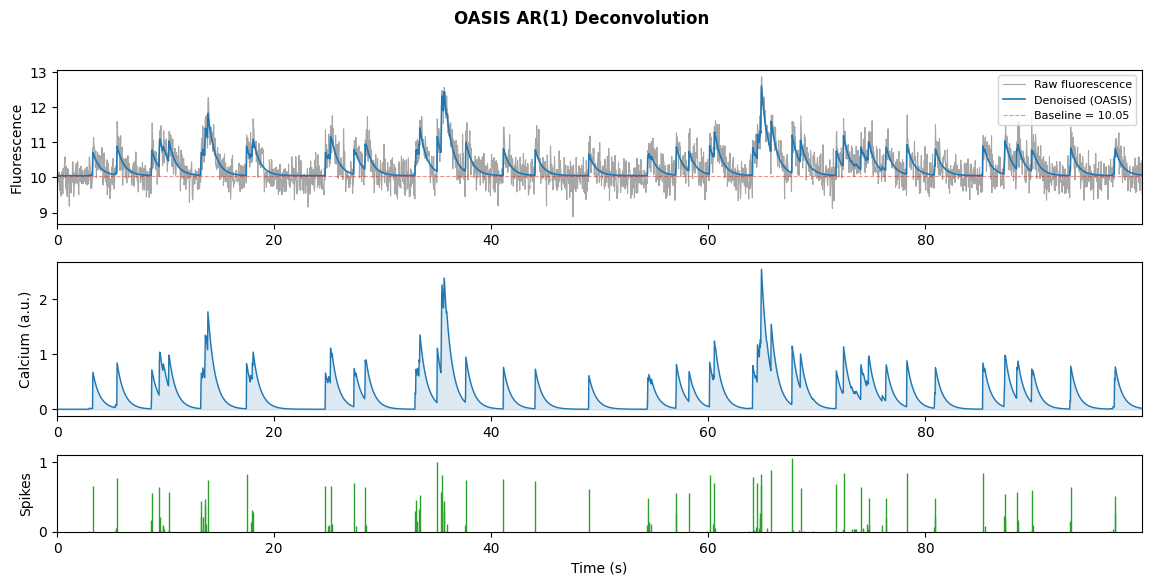

In [5]:
# Visualize
fig, axes = plot_deconvolution(
    y, c, sp, bl=bl, framerate=framerate,
    title='OASIS AR(1) Deconvolution', show=True)

## 3. AR(1) with Auto-Estimated Parameters

OASIS can automatically estimate noise and AR coefficients from the data.

In [6]:
# Auto-estimate all parameters
c_auto, bl_auto, c1_auto, g_auto, sn_auto, sp_auto, lam_auto = constrained_foopsi(y, p=1)

print(f"Auto-estimated:")
print(f"  g = {g_auto} (true: {g_ar1})")
print(f"  sn = {sn_auto:.3f} (true: {sn})")
print(f"  bl = {bl_auto:.3f}")
print(f"  Calcium corr: {np.corrcoef(c_auto, trueC[0])[0,1]:.4f}")

Auto-estimated:
  g = [0.94970691] (true: [0.95])
  sn = 0.299 (true: 0.3)
  bl = 10.048
  Calcium corr: 0.9842


## 4. AR(2) Deconvolution

AR(2) models capture both rise and decay dynamics of calcium transients.

AR(2) results:
  Calcium corr: 0.9995
  Spike corr:   0.9582


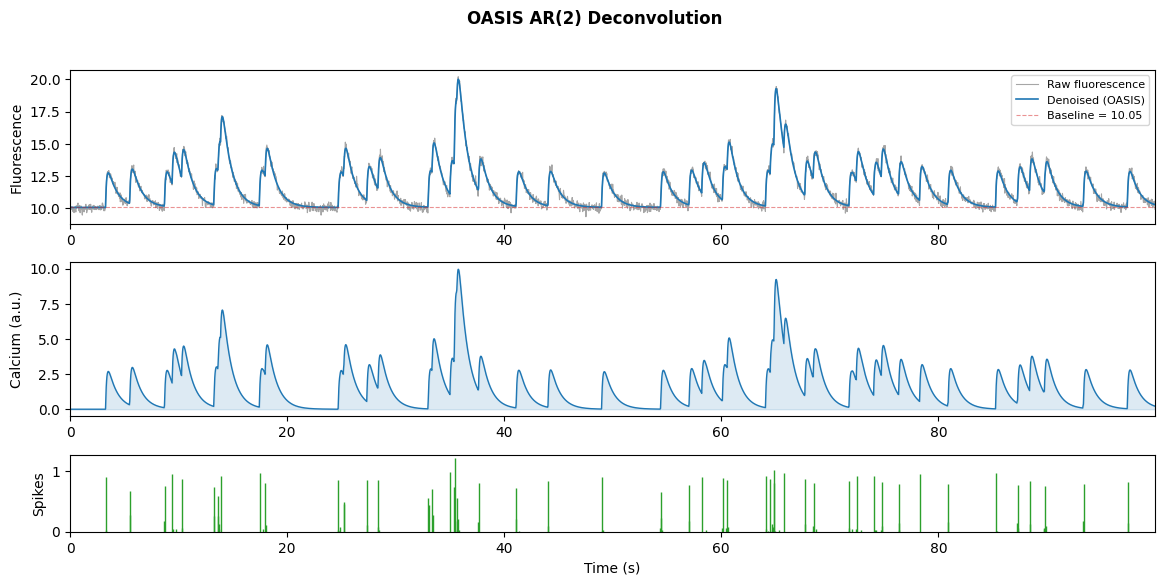

In [7]:
# Generate AR(2) data
g_ar2 = [1.7, -0.71]
Y2, trueC2, trueS2 = gen_data(g=g_ar2, sn=0.2, T=3000, framerate=30, seed=0)
y2 = Y2[0]

# Deconvolve
c2, bl2, c1_2, g2_est, sn2_est, sp2, lam2 = constrained_foopsi(
    y2, g=np.array(g_ar2), sn=0.2, p=2)

print(f"AR(2) results:")
print(f"  Calcium corr: {np.corrcoef(c2, trueC2[0])[0,1]:.4f}")
print(f"  Spike corr:   {np.corrcoef(sp2, trueS2[0])[0,1]:.4f}")

fig2, axes2 = plot_deconvolution(
    y2, c2, sp2, bl=bl2, framerate=30,
    title='OASIS AR(2) Deconvolution', show=True)

## 5. Compare AR(1) vs AR(2)

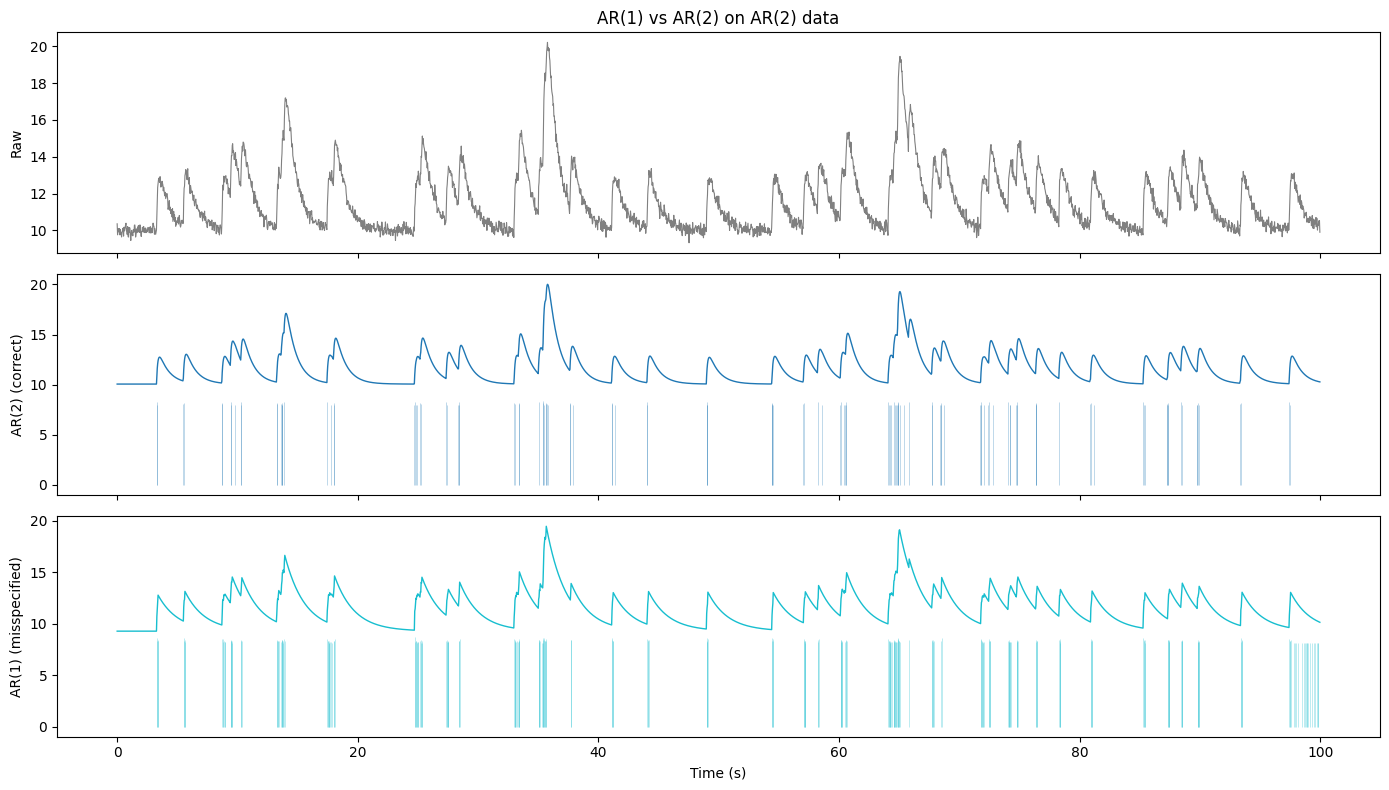

In [8]:
# Run AR(1) on the AR(2) data for comparison
c2_ar1, bl2_ar1, _, _, _, sp2_ar1, _ = constrained_foopsi(y2, p=1)

fig3, axes3 = plot_comparison(
    y2,
    [(c2, sp2, bl2), (c2_ar1, sp2_ar1, bl2_ar1)],
    labels=['AR(2) (correct)', 'AR(1) (misspecified)'],
    framerate=30,
    title='AR(1) vs AR(2) on AR(2) data',
    show=True)

## 6. Effect of Noise Level

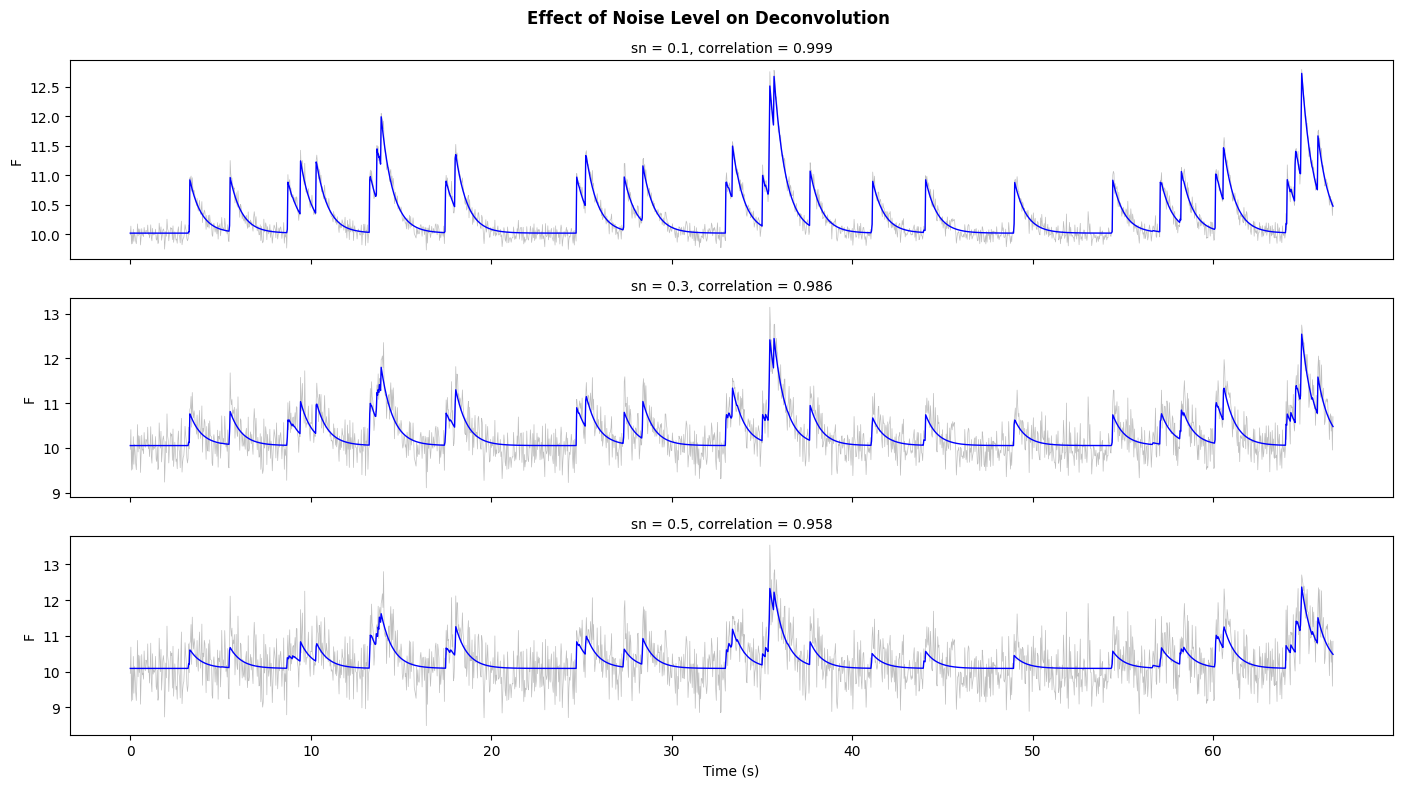

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, noise in enumerate([0.1, 0.3, 0.5]):
    Y_n, C_n, S_n = gen_data(g=[0.95], sn=noise, T=2000, seed=0)
    y_n = Y_n[0]
    c_n, bl_n, _, _, _, sp_n, _ = constrained_foopsi(y_n, g=np.array([0.95]), sn=noise, p=1)
    
    t = np.arange(len(y_n)) / 30
    axes[i].plot(t, y_n, 'gray', alpha=0.5, lw=0.5)
    axes[i].plot(t, c_n + bl_n, 'b', lw=1)
    corr = np.corrcoef(c_n, C_n[0])[0,1]
    axes[i].set_title(f'sn = {noise}, correlation = {corr:.3f}', fontsize=10)
    axes[i].set_ylabel('F')

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Effect of Noise Level on Deconvolution', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Zoomed View

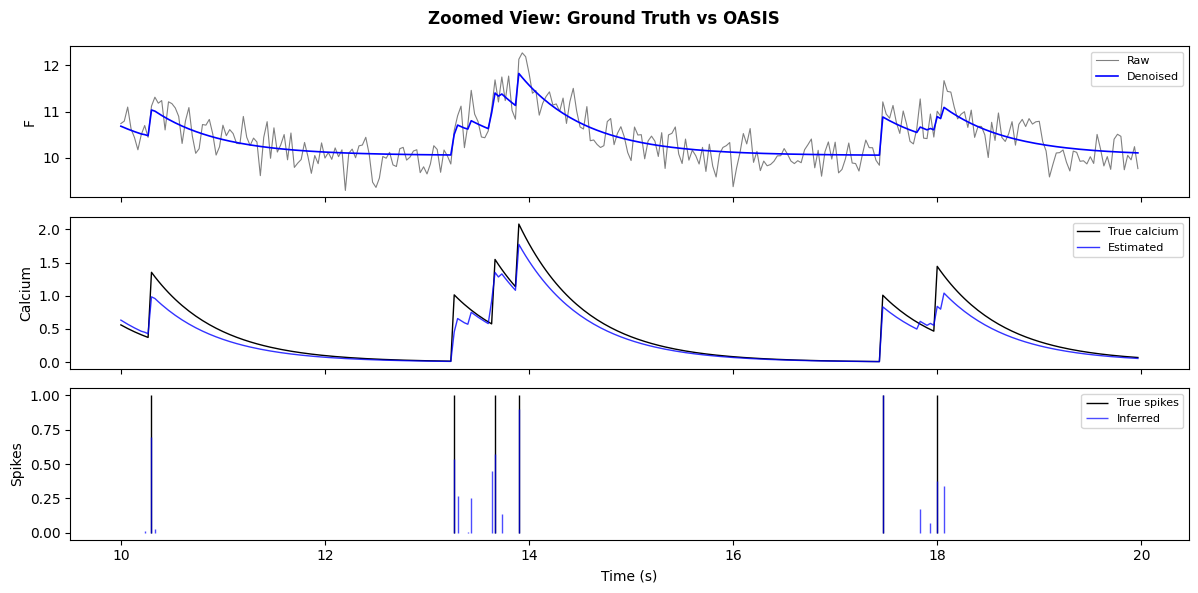

In [10]:
# Zoom into a 10-second window
start, end = 300, 600  # frames 10-20s at 30Hz
t_zoom = np.arange(start, end) / framerate

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

ax1.plot(t_zoom, y[start:end], 'gray', lw=0.8, label='Raw')
ax1.plot(t_zoom, c[start:end] + bl, 'b', lw=1.2, label='Denoised')
ax1.legend(fontsize=8)
ax1.set_ylabel('F')

ax2.plot(t_zoom, trueC[0][start:end], 'k', lw=1, label='True calcium')
ax2.plot(t_zoom, c[start:end], 'b', lw=1, alpha=0.8, label='Estimated')
ax2.legend(fontsize=8)
ax2.set_ylabel('Calcium')

ax3.vlines(t_zoom[trueS[0][start:end] > 0], 0, 1, 'k', lw=1, label='True spikes')
spike_idx = np.where(sp[start:end] > 0)[0]
if len(spike_idx) > 0:
    ax3.vlines(t_zoom[spike_idx], 0, sp[start:end][spike_idx] / sp[start:end].max(),
               'b', lw=1, alpha=0.7, label='Inferred')
ax3.legend(fontsize=8)
ax3.set_ylabel('Spikes')
ax3.set_xlabel('Time (s)')

fig.suptitle('Zoomed View: Ground Truth vs OASIS', fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:
1. **AR(1) deconvolution** with known and auto-estimated parameters
2. **AR(2) deconvolution** capturing rise/decay dynamics
3. **Comparison** of AR(1) vs AR(2) on the same data
4. **Noise sensitivity** analysis
5. **Visualization** of traces, calcium signals, and spike trains